In [3]:
!pip install -q kaggle
import os, getpass

os.makedirs('/root/.kaggle', exist_ok=True)
token = getpass.getpass("Paste your Kaggle API token (input is hidden): ")
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(token.strip())
os.chmod('/root/.kaggle/access_token', 0o600)
del token

!kaggle datasets download -d kayvanshah/landmarks-dataset -p /content/data --unzip
!ls /content/data

Paste your Kaggle API token (input is hidden): ··········
Dataset URL: https://www.kaggle.com/datasets/kayvanshah/landmarks-dataset
License(s): DbCL-1.0
100% 182M/182M [00:01<00:00, 113MB/s]

Gothic	Modern	Mughal	Neoclassical  Pagodas  Pyramids


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

# EDIT THIS after inspecting !ls /content/data above so it points at the folder
# whose immediate children are class folders, e.g. /content/data/train
DATA_DIR = pathlib.Path('/content/data')
print("Classes found:", [p.name for p in DATA_DIR.iterdir() if p.is_dir()])

Classes found: ['Neoclassical', 'Pagodas', 'Pyramids', 'Modern', 'Mughal', 'Gothic']


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='training', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='validation', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
normalize = tf.keras.layers.Rescaling(1./127.5, offset=-1)  # match MobileNetV2 preprocessing
train_ds = train_ds.map(lambda x, y: (normalize(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalize(x), y)).prefetch(AUTOTUNE)

Found 420 files belonging to 6 classes.
Using 336 files for training.
Found 420 files belonging to 6 classes.
Using 84 files for validation.
['Gothic', 'Modern', 'Mughal', 'Neoclassical', 'Pagodas', 'Pyramids']


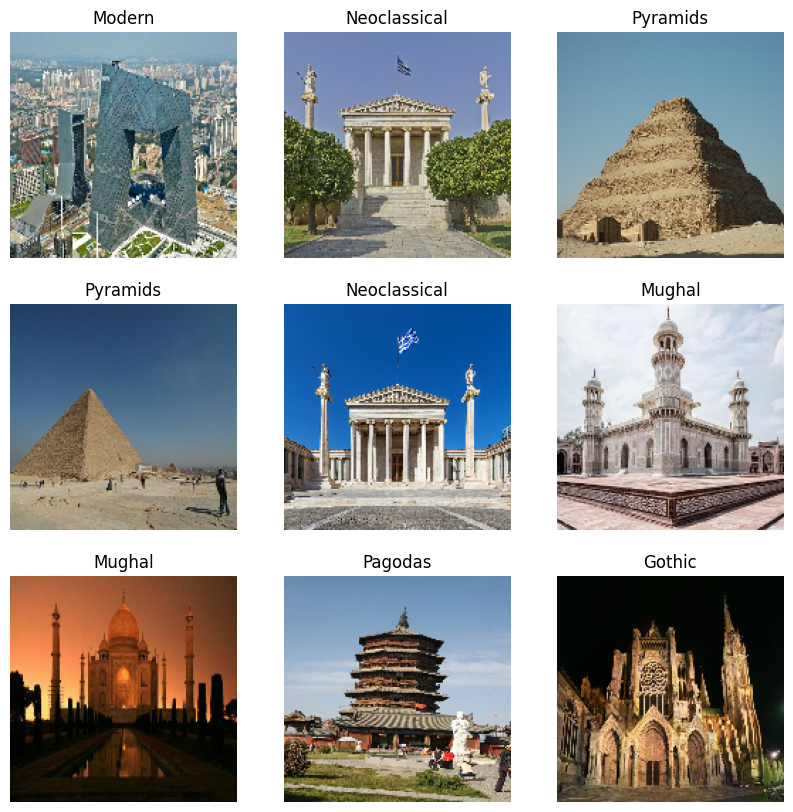

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow((images[i].numpy() + 1) / 2)
        plt.title(class_names[labels[i]])
        plt.axis('off')

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
import os
from PIL import Image

fixed = 0
removed = 0
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

for root, dirs, files in os.walk(DATA_DIR):
    for fname in files:
        if not fname.lower().endswith(valid_exts):
            continue
        fpath = os.path.join(root, fname)
        try:
            with Image.open(fpath) as img:
                img = img.convert('RGB')
                img.save(fpath, format='JPEG')
            fixed += 1
        except Exception:
            os.remove(fpath)
            removed += 1

print(f"Re-encoded {fixed} images, removed {removed} unreadable files")

Re-encoded 420 images, removed 0 unreadable files


In [13]:
EPOCHS = 12
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

Epoch 1/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 451ms/step - accuracy: 0.4821 - loss: 1.3865 - val_accuracy: 0.5833 - val_loss: 1.1317
Epoch 2/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 236ms/step - accuracy: 0.6726 - loss: 0.9133 - val_accuracy: 0.7262 - val_loss: 0.8043
Epoch 3/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.7976 - loss: 0.6711 - val_accuracy: 0.7857 - val_loss: 0.6868
Epoch 4/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - accuracy: 0.8452 - loss: 0.5184 - val_accuracy: 0.8214 - val_loss: 0.5865
Epoch 5/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.8750 - loss: 0.4449 - val_accuracy: 0.8452 - val_loss: 0.5342
Epoch 6/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.8690 - loss: 0.4290 - val_accuracy: 0.8810 - val_loss: 0.4760
Epoch 7/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.9077 - loss: 0.3229 - val_accuracy: 0.8810 - val_loss: 0.4418
Epoch 8/12
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 0.9196 - loss: 0.3143 - val_accuracy: 0.

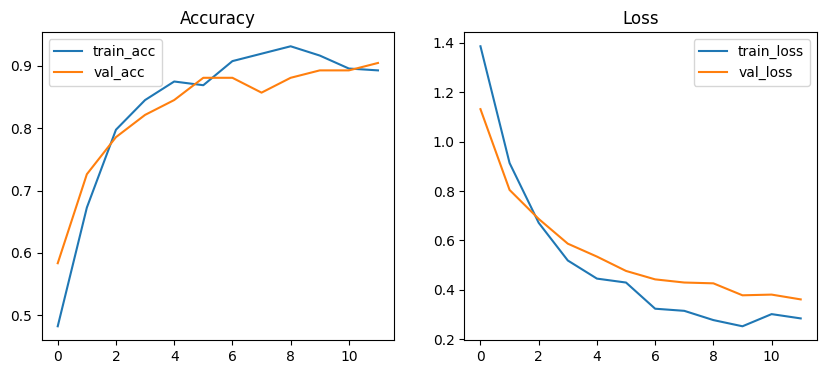

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.show()

In [15]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.6964 - loss: 0.9302 - val_accuracy: 0.9048 - val_loss: 0.3481
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.7143 - loss: 0.8858 - val_accuracy: 0.8929 - val_loss: 0.3360
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.7500 - loss: 0.7589 - val_accuracy: 0.9048 - val_loss: 0.3252
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.7530 - loss: 0.7398 - val_accuracy: 0.9048 - val_loss: 0.3142
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.7976 - loss: 0.6337 - val_accuracy: 0.9167 - val_loss: 0.3058


In [16]:
loss, acc = model.evaluate(val_ds)
print(f"Final validation accuracy: {acc*100:.2f}%")

model.save('landmark_classifier.h5')
print("Saved as landmark_classifier.h5")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.9167 - loss: 0.3058


Final validation accuracy: 91.67%
Saved as landmark_classifier.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


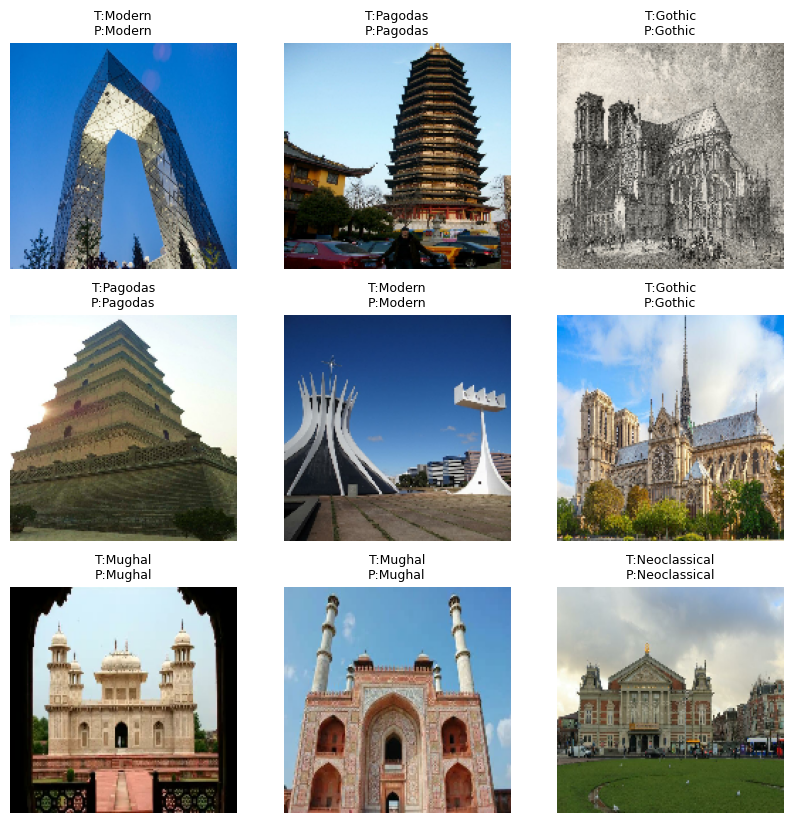

In [17]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    plt.figure(figsize=(10, 10))
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow((images[i].numpy() + 1) / 2)
        true_l = class_names[labels[i]]
        pred_l = class_names[np.argmax(preds[i])]
        plt.title(f"T:{true_l}\nP:{pred_l}", fontsize=9)
        plt.axis('off')
    break